# C-MAPSS model experiment plan

This notebook runs experiments without the Dash interface.

It covers:

1. Import and project validation.
2. Reproducible train/validation motor splits.
3. All tabular models:
   - Linear Regression
   - Ridge
   - Elastic Net
   - Random Forest
   - Extra Trees
   - HistGradientBoosting
   - XGBoost
   - SVR
4. All sequence models:
   - LSTM
   - GRU
   - CNN
   - CNN-LSTM
5. Optional GroupKFold cross-validation for tabular models.
6. Official C-MAPSS test evaluation for every successful experiment.
7. Comparison by validation and official NASA score, MAE, and RMSE.
8. CSV exports of the final rankings.

## Recommended execution strategy

**Stage 1 — smoke test**

Run every model on `FD001` with a modest configuration. This confirms that preprocessing, feature selection, saving, loading, and official testing work.

**Stage 2 — model-family comparison**

Compare all successful models using the same datasets, RUL clipping, validation motors, random seed, and feature columns.

**Stage 3 — focused tuning**

Take the best two or three tabular models and best one or two sequence models, then add parameter variations to `EXPERIMENT_SPECS`.

**Stage 4 — final official comparison**

Rank the frozen experiments by official NASA score. Do not tune parameters using the official test results; use validation results for selection and treat the official test as the final report.


In [1]:
from __future__ import annotations

import gc
import json
import random
import sys
import time
import traceback
from copy import deepcopy
from datetime import datetime
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)


## 1. Locate the project and import its classes

Place this notebook anywhere inside the repository. The cell searches upward until it finds `models/`, `utils/`, and `cmapss_dash_lab/`.


In [2]:
def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()

    for candidate in [current, *current.parents]:
        if (
            (candidate / "models").is_dir()
            and (candidate / "utils").is_dir()
            and (candidate / "cmapss_dash_lab").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root. Run the notebook from inside "
        "the predictive-maintenance repository."
    )


PROJECT_ROOT = find_project_root()
PROJECT_ROOT


PosixPath('/home/lewagon/code/feremiev/predictive_maintenance/predictive_maintenance_dds04')

In [ ]:
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DASH_FOLDER = PROJECT_ROOT / "cmapss_dash_lab"

if str(DASH_FOLDER) not in sys.path:
    sys.path.insert(0, str(DASH_FOLDER))

from services import (
    AVAILABLE_SEQUENCE_MODELS,
    AVAILABLE_TABULAR_MODELS,
    ExperimentService,
    load_project_classes,
)

PROJECT_CLASSES, IMPORT_ERROR = load_project_classes()

if IMPORT_ERROR:
    raise ImportError(IMPORT_ERROR)

SERVICE = ExperimentService(
    PROJECT_CLASSES,
    experiments_folder=PROJECT_ROOT / "experiments_f004_base",
)

print("Project root:", PROJECT_ROOT)
print("Tabular models:", AVAILABLE_TABULAR_MODELS)
print("Sequence models:", AVAILABLE_SEQUENCE_MODELS)


I0000 00:00:1784040786.674956   40824 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784040786.781508   40824 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784040789.444432   40824 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Project root: /home/lewagon/code/feremiev/predictive_maintenance/predictive_maintenance_dds04
Tabular models: ['linear', 'ridge', 'elastic_net', 'random_forest', 'extra_trees', 'hist_gradient_boosting', 'xgboost', 'svr']
Sequence models: ['lstm', 'gru', 'cnn', 'cnn_lstm']


## 2. Global execution settings

Keep these values fixed while comparing models.

The notebook defaults to `FD001`, clipped RUL at 125, 20 held-out validation motors, and random seed 42.

Set `RUN_TABULAR_CV = True` to calculate five-fold GroupKFold results. This adds substantial runtime because each tabular model is fitted five extra times.

Set `RUN_EXTERNAL_TEST = True` to run the official final-cycle/final-window evaluation after each experiment.


In [ ]:
DATA_FOLDER = PROJECT_ROOT / "raw_data"
DATASETS = ["FD004"]

REMOVE_NULLS = True
CLIP_RUL = True
RUL_CAP = 125

TARGET_COLUMN = "RUL"
GROUP_COLUMN = "unique_motor_id"
TIME_COLUMN = "cycle"

# None uses the model's automatic processed-feature selection.
# Example: ["sensor_1", "sensor_2"]
FEATURE_COLUMNS: list[str] | None = None

COLUMNS_TO_DROP = [
    "dataset",
    "unit_number",
]

VALIDATION_GROUP_COUNT = 20
GROUP_SELECTION = "random"
RANDOM_STATE = 42

RUN_TABULAR_CV = False
CV_FOLDS = 5
RUN_EXTERNAL_TEST = True
SKIP_EXISTING_EXPERIMENTS = True
STOP_ON_ERROR = False

# Sequence defaults
WINDOW_TYPE = "sliding"
WINDOW_SIZE = 30
MIN_WINDOW_SIZE = 10
MAX_WINDOW_SIZE = 60
STRIDE = 1
PREDICTION_HORIZON = 0
SCALER = "standard"
EPOCHS = 100
BATCH_SIZE = 64
LEARNING_RATE = 0.001
PATIENCE = 12
LOSS = "huber"

assert DATA_FOLDER.exists(), f"Raw-data folder not found: {DATA_FOLDER}"


## 3. Reproducibility

The same seed and validation-motor selection are used for all models. This is essential: otherwise differences could come from different validation engines instead of model quality.


In [5]:
def set_global_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)

    try:
        import tensorflow as tf

        tf.keras.utils.set_random_seed(seed)

        try:
            tf.config.experimental.enable_op_determinism()
        except Exception:
            pass

    except ImportError:
        pass


set_global_seed(RANDOM_STATE)


## 4. Experiment catalogue

Each model gets one baseline configuration.

After the baseline run, add targeted variations rather than creating a very large blind grid. Sequence experiments are especially expensive.

The experiment name includes the dataset and configuration label, so every saved folder is easy to identify.


In [6]:
TABULAR_SPECS: list[dict[str, Any]] = [
    {
        "label": "linear_default",
        "model_name": "linear",
        "model_params": {},
    },
    {
        "label": "ridge_alpha_1",
        "model_name": "ridge",
        "model_params": {
            "alpha": 1.0,
        },
    },
    {
        "label": "elastic_net_default",
        "model_name": "elastic_net",
        "model_params": {
            "alpha": 0.1,
            "l1_ratio": 0.5,
            "max_iter": 10_000,
        },
    },
    {
        "label": "random_forest_baseline",
        "model_name": "random_forest",
        "model_params": {
            "n_estimators": 300,
            "min_samples_leaf": 2,
            "n_jobs": -1,
            "random_state": RANDOM_STATE,
        },
    },
    {
        "label": "extra_trees_baseline",
        "model_name": "extra_trees",
        "model_params": {
            "n_estimators": 300,
            "min_samples_leaf": 2,
            "n_jobs": -1,
            "random_state": RANDOM_STATE,
        },
    },
    {
        "label": "hist_gradient_boosting_baseline",
        "model_name": "hist_gradient_boosting",
        "model_params": {
            "learning_rate": 0.08,
            "max_iter": 300,
            "max_leaf_nodes": 31,
            "l2_regularization": 1.0,
            "random_state": RANDOM_STATE,
        },
    },
    {
        "label": "xgboost_baseline",
        "model_name": "xgboost",
        "model_params": {
            "objective": "reg:squarederror",
            "n_estimators": 500,
            "learning_rate": 0.05,
            "max_depth": 6,
            "min_child_weight": 3,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "reg_alpha": 0.0,
            "reg_lambda": 1.0,
            "random_state": RANDOM_STATE,
            "n_jobs": -1,
            "tree_method": "hist",
            "eval_metric": "mae",
        },
    },
    {
        "label": "svr_rbf_baseline",
        "model_name": "svr",
        "model_params": {
            "kernel": "rbf",
            "C": 10.0,
            "epsilon": 0.1,
            "gamma": "scale",
        },
    },
]


SEQUENCE_SPECS: list[dict[str, Any]] = [
    {
        "label": "lstm_baseline",
        "model_name": "lstm",
        "model_params": {},
    },
    {
        "label": "gru_baseline",
        "model_name": "gru",
        "model_params": {},
    },
    {
        "label": "cnn_baseline",
        "model_name": "cnn",
        "model_params": {},
    },
    {
        "label": "cnn_lstm_baseline",
        "model_name": "cnn_lstm",
        "model_params": {},
    },
]

print(
    f"Planned baseline experiments: "
    f"{len(TABULAR_SPECS)} tabular + "
    f"{len(SEQUENCE_SPECS)} sequence"
)


Planned baseline experiments: 8 tabular + 4 sequence


## 5. Build service-compatible configurations

These dictionaries use the same fields as the Dash application, so the notebook exercises the same model classes, preprocessing, experiment manager, and external evaluator.


In [7]:
RUN_PREFIX = datetime.now().strftime("%Y%m%d_%H%M%S")


def common_config() -> dict[str, Any]:
    return {
        "data_folder": str(DATA_FOLDER),
        "datasets": list(DATASETS),
        "remove_nulls": REMOVE_NULLS,
        "clip_rul": CLIP_RUL,
        "rul_cap": RUL_CAP,
        "target_column": TARGET_COLUMN,
        "group_column": GROUP_COLUMN,
        "time_column": TIME_COLUMN,
        "columns_to_drop": list(COLUMNS_TO_DROP),
        "feature_columns": (
            None
            if FEATURE_COLUMNS is None
            else list(FEATURE_COLUMNS)
        ),
        "validation_group_count": VALIDATION_GROUP_COUNT,
        "group_selection": GROUP_SELECTION,
        "random_state": RANDOM_STATE,
    }


def build_tabular_config(spec: dict[str, Any]) -> dict[str, Any]:
    config = common_config()

    config.update(
        {
            "model_family": "tabular",
            "model_name": spec["model_name"],
            "experiment_name": (
                f"{RUN_PREFIX}_{'_'.join(DATASETS)}_{spec['label']}"
            ),
            "model_params": deepcopy(spec.get("model_params", {})),
            "window_type": None,
            "window_size": None,
            "min_window_size": None,
            "max_window_size": None,
            "stride": None,
            "prediction_horizon": None,
            "scaler": None,
            "epochs": None,
            "batch_size": None,
            "learning_rate": None,
            "patience": None,
            "loss": None,
        }
    )

    return config


def build_sequence_config(spec: dict[str, Any]) -> dict[str, Any]:
    config = common_config()

    config.update(
        {
            "model_family": "sequence",
            "model_name": spec["model_name"],
            "experiment_name": (
                f"{RUN_PREFIX}_{'_'.join(DATASETS)}_{spec['label']}"
            ),
            "model_params": deepcopy(spec.get("model_params", {})),
            "window_type": WINDOW_TYPE,
            "window_size": WINDOW_SIZE,
            "min_window_size": MIN_WINDOW_SIZE,
            "max_window_size": MAX_WINDOW_SIZE,
            "stride": STRIDE,
            "prediction_horizon": PREDICTION_HORIZON,
            "scaler": SCALER,
            "epochs": EPOCHS,
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "patience": PATIENCE,
            "loss": LOSS,
        }
    )

    return config


EXPERIMENT_CONFIGS = (
    [build_tabular_config(spec) for spec in TABULAR_SPECS]
    + [build_sequence_config(spec) for spec in SEQUENCE_SPECS]
)

pd.DataFrame(
    [
        {
            "experiment_name": config["experiment_name"],
            "model_family": config["model_family"],
            "model_name": config["model_name"],
            "datasets": ",".join(config["datasets"]),
            "feature_count_requested": (
                "automatic"
                if config["feature_columns"] is None
                else len(config["feature_columns"])
            ),
        }
        for config in EXPERIMENT_CONFIGS
    ]
)


,experiment_name,model_family,model_name,datasets,feature_count_requested
0,20260714_145309_FD002_linear_default,tabular,linear,FD002,automatic
1,20260714_145309_FD002_ridge_alpha_1,tabular,ridge,FD002,automatic
2,20260714_145309_FD002_elastic_net_default,tabular,elastic_net,FD002,automatic
3,20260714_145309_FD002_random_forest_baseline,tabular,random_forest,FD002,automatic
4,20260714_145309_FD002_extra_trees_baseline,tabular,extra_trees,FD002,automatic
5,20260714_145309_FD002_hist_gradient_boosting_b...,tabular,hist_gradient_boosting,FD002,automatic
6,20260714_145309_FD002_xgboost_baseline,tabular,xgboost,FD002,automatic
7,20260714_145309_FD002_svr_rbf_baseline,tabular,svr,FD002,automatic
8,20260714_145309_FD002_lstm_baseline,sequence,lstm,FD002,automatic
9,20260714_145309_FD002_gru_baseline,sequence,gru,FD002,automatic


## 6. Optional GroupKFold evaluation for tabular models

The folds keep complete motors together. No cycles from one motor can appear in both the training and validation portions of a fold.

This function uses the same preprocessing and model constructor as the application. It is optional because it retrains every tabular model once per fold.


In [8]:
def run_tabular_cross_validation(
    config: dict[str, Any],
) -> dict[str, float]:
    training_data = SERVICE.load_training_data(
        data_folder=config["data_folder"],
        datasets=config["datasets"],
        remove_nulls=config["remove_nulls"],
        clip_rul=config["clip_rul"],
        rul_cap=config["rul_cap"],
    )

    experiment = SERVICE._create_tabular_model(
        training_data,
        config,
    )

    return experiment.cross_validation(
        cv=CV_FOLDS
    )


## 7. Experiment runner

For every configuration, the notebook:

1. Optionally runs GroupKFold cross-validation for tabular models.
2. Trains and saves the development experiment.
3. Records train and validation metrics.
4. Runs the official test.
5. Saves official predictions and metrics into the same experiment folder.
6. Clears TensorFlow state after sequence models.
7. Continues after failures and records the traceback.


In [9]:
def metric_value(
    values: dict[str, Any] | None,
    key: str,
) -> float | None:
    if not isinstance(values, dict):
        return None

    value = values.get(key)

    if value is None:
        return None

    try:
        return float(value)
    except (TypeError, ValueError):
        return None


def experiment_folder_exists(
    experiment_name: str,
) -> bool:
    return (
        SERVICE.experiments_folder
        / experiment_name
    ).exists()


def run_one_experiment(
    config: dict[str, Any],
) -> dict[str, Any]:
    name = config["experiment_name"]
    family = config["model_family"]

    row: dict[str, Any] = {
        "experiment_name": name,
        "model_family": family,
        "model_name": config["model_name"],
        "datasets": ",".join(config["datasets"]),
        "status": "started",
        "error": None,
        "elapsed_seconds": None,
    }

    started = time.perf_counter()

    try:
        set_global_seed(config["random_state"])

        if (
            SKIP_EXISTING_EXPERIMENTS
            and experiment_folder_exists(name)
        ):
            row["status"] = "skipped_existing"
            return row

        if RUN_TABULAR_CV and family == "tabular":
            cv_summary = run_tabular_cross_validation(
                config
            )

            row.update(
                {
                    f"cv_{key}": value
                    for key, value in cv_summary.items()
                }
            )

        development = SERVICE.run_and_save(
            config
        )

        saved_name = development[
            "experiment_name"
        ]

        row["experiment_name"] = saved_name

        development_metrics = development.get(
            "metrics",
            {},
        )

        train_metrics = development_metrics.get(
            "train",
            {},
        )

        validation_metrics = development_metrics.get(
            "validation",
            {},
        )

        for metric in (
            "NASA_SCORE",
            "MEAN_NASA_SCORE",
            "MAE",
            "RMSE",
            "R2",
            "MAPE",
            "Bias",
        ):
            row[f"train_{metric}"] = metric_value(
                train_metrics,
                metric,
            )

            row[f"validation_{metric}"] = metric_value(
                validation_metrics,
                metric,
            )

        if RUN_EXTERNAL_TEST:
            external = SERVICE.run_external_test(
                experiment_name=saved_name,
                data_folder=str(DATA_FOLDER),
                datasets=list(DATASETS),
                clip_rul=CLIP_RUL,
                rul_cap=RUL_CAP,
            )

            external_metrics = external.get(
                "metrics",
                {},
            )

            for metric in (
                "NASA_SCORE",
                "MEAN_NASA_SCORE",
                "MAE",
                "RMSE",
                "R2",
                "MAPE",
                "Bias",
            ):
                row[f"external_{metric}"] = metric_value(
                    external_metrics,
                    metric,
                )

            row["external_motor_count"] = (
                external_metrics.get(
                    "motor_count"
                )
            )

        row["status"] = "completed"

    except Exception as exc:
        row["status"] = "failed"
        row["error"] = (
            f"{type(exc).__name__}: {exc}"
        )
        row["traceback"] = traceback.format_exc()

        print(
            f"\nFAILED: {name}\n"
            f"{row['error']}\n"
        )

        if STOP_ON_ERROR:
            raise

    finally:
        row["elapsed_seconds"] = (
            time.perf_counter() - started
        )

        if family == "sequence":
            try:
                import tensorflow as tf

                tf.keras.backend.clear_session()
            except Exception:
                pass

        gc.collect()

    return row


## 8. Execute all experiments

Sequence models can take much longer than tabular models. Run this cell when ready.

Results are written after every experiment, so an interrupted notebook can be inspected without losing completed runs.


In [10]:
RESULTS_PATH = (
    PROJECT_ROOT
    / f"experiment_results_{RUN_PREFIX}.csv"
)

ERRORS_PATH = (
    PROJECT_ROOT
    / f"experiment_errors_{RUN_PREFIX}.json"
)

results: list[dict[str, Any]] = []

for position, config in enumerate(
    EXPERIMENT_CONFIGS,
    start=1,
):
    print(
        f"\n{'=' * 80}\n"
        f"[{position}/{len(EXPERIMENT_CONFIGS)}] "
        f"{config['experiment_name']}\n"
        f"{'=' * 80}"
    )

    row = run_one_experiment(
        config
    )

    results.append(row)

    pd.DataFrame(results).to_csv(
        RESULTS_PATH,
        index=False,
    )

    failures = [
        item
        for item in results
        if item.get("status") == "failed"
    ]

    ERRORS_PATH.write_text(
        json.dumps(
            failures,
            indent=2,
            default=str,
        ),
        encoding="utf-8",
    )

    print(
        "Status:",
        row["status"],
        "| elapsed:",
        round(row["elapsed_seconds"], 1),
        "seconds",
    )

results_df = pd.DataFrame(results)
results_df



[1/12] 20260714_145309_FD002_linear_default


Training series: 240 | Validation series: 20
Training rows: 49,404 | Validation rows: 4,355
✅ Experiment saved at: /home/lewagon/code/feremiev/predictive_maintenance/predictive_maintenance_dds04/experiments/20260714_145309_FD002_linear_default
Training series: 240 | Validation series: 20
Training rows: 49,404 | Validation rows: 4,355
✅ External test added to: /home/lewagon/code/feremiev/predictive_maintenance/predictive_maintenance_dds04/experiments/20260714_145309_FD002_linear_default
Status: completed | elapsed: 5.8 seconds

[2/12] 20260714_145309_FD002_ridge_alpha_1
Training series: 240 | Validation series: 20
Training rows: 49,404 | Validation rows: 4,355
✅ Experiment saved at: /home/lewagon/code/feremiev/predictive_maintenance/predictive_maintenance_dds04/experiments/20260714_145309_FD002_ridge_alpha_1
Training series: 240 | Validation series: 20
Training rows: 49,404 | Validation rows: 4,355
✅ External test added to: /home/lewagon/code/feremiev/predictive_maintenance/predictive_m

/home/lewagon/.pyenv/versions/predictive_maintenance/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.482e+06, tolerance: 8.583e+03
  model = cd_fast.enet_coordinate_descent(
/home/lewagon/.pyenv/versions/predictive_maintenance/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.526e+05, tolerance: 1.762e+03
  model = cd_fast.enet_coordinate_descent(
/home/lewagon/.pyenv/versions/predictive_maintenance/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number o

✅ Experiment saved at: /home/lewagon/code/feremiev/predictive_maintenance/predictive_maintenance_dds04/experiments/20260714_145309_FD002_elastic_net_default
Training series: 240 | Validation series: 20
Training rows: 49,404 | Validation rows: 4,355
✅ External test added to: /home/lewagon/code/feremiev/predictive_maintenance/predictive_maintenance_dds04/experiments/20260714_145309_FD002_elastic_net_default
Status: completed | elapsed: 77.7 seconds

[4/12] 20260714_145309_FD002_random_forest_baseline
Training series: 240 | Validation series: 20
Training rows: 49,404 | Validation rows: 4,355
✅ Experiment saved at: /home/lewagon/code/feremiev/predictive_maintenance/predictive_maintenance_dds04/experiments/20260714_145309_FD002_random_forest_baseline
Training series: 240 | Validation series: 20
Training rows: 49,404 | Validation rows: 4,355
✅ External test added to: /home/lewagon/code/feremiev/predictive_maintenance/predictive_maintenance_dds04/experiments/20260714_145309_FD002_random_fores

E0000 00:00:1784043237.073556   40824 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


...

E0000 00:00:1784045339.421087   40824 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


 — val_nasa_score: 424513.743554
671/671 ━━━━━━━━━━━━━━━━━━━━ 27s 40ms/step - loss: 125.3400 - mae: 16.8203 - rmse: 22.1632 - val_loss: 144.3815 - val_mae: 18.9369 - val_rmse: 24.8539 - val_nasa_score: 424513.7436 - learning_rate: 2.5000e-04
Epoch 18: early stopping
Restoring model weights from the end of the best epoch: 6.


E0000 00:00:1784045352.464119   40824 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


✅ Experiment saved at: /home/lewagon/code/feremiev/predictive_maintenance/predictive_maintenance_dds04/experiments/20260714_145309_FD002_cnn_lstm_baseline
✅ External test added to: /home/lewagon/code/feremiev/predictive_maintenance/predictive_maintenance_dds04/experiments/20260714_145309_FD002_cnn_lstm_baseline
Status: completed | elapsed: 508.9 seconds


,experiment_name,model_family,model_name,datasets,status,error,elapsed_seconds,train_NASA_SCORE,validation_NASA_SCORE,train_MEAN_NASA_SCORE,validation_MEAN_NASA_SCORE,train_MAE,validation_MAE,train_RMSE,validation_RMSE,train_R2,validation_R2,train_MAPE,validation_MAPE,train_Bias,validation_Bias,external_NASA_SCORE,external_MEAN_NASA_SCORE,external_MAE,external_RMSE,external_R2,external_MAPE,external_Bias,external_motor_count
0,20260714_145309_FD002_linear_default,tabular,linear,FD002,completed,None,5.835104,5.526316e+05,6.571473e+04,NaN,NaN,17.574103,19.604310,21.725221,24.316620,0.728312,0.655802,50.481682,49.734963,-5.251446e-13,2.352650,2769.613478,NaN,17.483237,21.323913,0.753382,53.049782,-1.192890,259
1,20260714_145309_FD002_ridge_alpha_1,tabular,ridge,FD002,completed,None,5.473821,5.661241e+05,6.712150e+04,NaN,NaN,17.713342,19.526171,21.881954,24.282289,0.724377,0.656773,50.585534,48.334358,-5.455514e-13,2.286080,2707.123204,NaN,17.318600,21.175666,0.756799,52.724787,-1.256947,259
2,20260714_145309_FD002_elastic_net_default,tabular,elastic_net,FD002,completed,None,77.659385,9.331293e+06,6.741204e+05,NaN,NaN,33.738114,33.552696,38.000845,37.480748,0.168755,0.182254,162.441852,154.116953,2.916038e-14,2.303912,74800.711544,NaN,34.078820,40.209581,0.123101,164.944517,-11.101948,259
3,20260714_145309_FD002_random_forest_baseline,tabular,random_forest,FD002,completed,None,577.721636,5.745993e+04,7.580647e+04,NaN,NaN,6.222657,16.549685,8.522067,22.079858,0.958195,0.716212,12.397571,30.471733,1.068935e-01,2.833965,1978.820825,NaN,13.092564,17.253192,0.838553,27.762337,-0.601717,259
4,20260714_145309_FD002_extra_trees_baseline,tabular,extra_trees,FD002,completed,None,152.064160,1.667317e+04,7.286384e+04,NaN,NaN,2.747866,16.455800,3.953266,21.926085,0.991004,0.720151,5.348842,30.348556,-1.610817e-17,2.759549,2412.172981,NaN,13.077144,17.372411,0.836314,28.662198,-0.674771,259
5,20260714_145309_FD002_hist_gradient_boosting_b...,tabular,hist_gradient_boosting,FD002,completed,None,33.835932,4.811183e+05,7.729460e+04,NaN,NaN,13.123743,16.537103,17.807662,22.122197,0.817461,0.715122,26.716588,31.156320,-1.453768e-03,2.684060,2371.520916,NaN,12.995804,17.426779,0.835288,26.833133,-0.682238,259
6,20260714_145309_FD002_xgboost_baseline,tabular,xgboost,FD002,completed,None,27.593875,3.515208e+05,7.533157e+04,NaN,NaN,12.034988,16.424649,16.391525,22.022356,0.845339,0.717688,24.196806,30.225127,-1.981813e-03,2.602251,2270.450321,NaN,13.153895,17.104264,0.841328,27.697927,-0.683114,259
7,20260714_145309_FD002_svr_rbf_baseline,tabular,svr,FD002,completed,None,1563.069260,6.801168e+07,5.630916e+06,NaN,NaN,35.646579,34.914544,44.354694,43.426242,-0.132457,-0.097757,217.672022,206.691982,-1.563471e+01,-13.525805,525905.819858,NaN,41.223593,51.469531,-0.436783,224.679149,-28.580729,259
8,20260714_145309_FD002_lstm_baseline,sequence,lstm,FD002,completed,None,669.241905,1.026207e+07,8.737347e+05,239.136605,264.287582,36.452710,36.191098,41.326511,41.495809,0.023174,-0.003262,199.941162,214.518388,-2.751938e+00,-6.572777,79777.076864,315.324414,37.232452,43.571578,-0.038200,182.085124,-11.088671,253
9,20260714_145309_FD002_gru_baseline,sequence,gru,FD002,completed,None,713.808801,5.585876e+05,2.908577e+04,13.016745,8.797872,19.299398,17.044134,24.323585,20.644654,0.661612,0.751675,41.777495,45.022345,9.069191e+00,2.759386,2713.178164,10.724024,17.371451,22.114988,0.732547,35.197514,7.935862,253


## 9. Validate that the requested features were actually used

For each saved experiment, inspect:

- `config.json` → requested raw `feature_columns`
- `feature_names.json` → features persisted by the model manager
- Keras input shape for sequence models
- sklearn raw input columns for tabular models

For a sequence model trained with two features and a window of 30, the model input should end in `(30, 2)`.


In [11]:
def inspect_saved_features(
    experiment_name: str,
) -> dict[str, Any]:
    loaded = SERVICE.manager.load_experiment(
        experiment_name
    )

    model_family = (
        loaded.metadata.get("model_family")
        or loaded.config.get("model_family")
    )

    model_input_shape = None

    if model_family in {
        "sequence",
        "tensorflow",
    }:
        model_input_shape = getattr(
            loaded.model,
            "input_shape",
            None,
        )

    return {
        "experiment_name": experiment_name,
        "model_family": model_family,
        "requested_feature_columns": loaded.config.get(
            "feature_columns"
        ),
        "saved_feature_names": loaded.feature_names,
        "model_input_shape": model_input_shape,
    }


completed_names = [
    row["experiment_name"]
    for row in results
    if row.get("status") == "completed"
]

feature_checks = pd.DataFrame(
    [
        inspect_saved_features(name)
        for name in completed_names
    ]
)

feature_checks


,experiment_name,model_family,requested_feature_columns,saved_feature_names,model_input_shape
0,20260714_145309_FD002_linear_default,sklearn,None,"[setting_1, setting_2, setting_3, sensor_1, se...",None
1,20260714_145309_FD002_ridge_alpha_1,sklearn,None,"[setting_1, setting_2, setting_3, sensor_1, se...",None
2,20260714_145309_FD002_elastic_net_default,sklearn,None,"[setting_1, setting_2, setting_3, sensor_1, se...",None
3,20260714_145309_FD002_random_forest_baseline,sklearn,None,"[setting_1, setting_2, setting_3, sensor_1, se...",None
4,20260714_145309_FD002_extra_trees_baseline,sklearn,None,"[setting_1, setting_2, setting_3, sensor_1, se...",None
5,20260714_145309_FD002_hist_gradient_boosting_b...,sklearn,None,"[setting_1, setting_2, setting_3, sensor_1, se...",None
6,20260714_145309_FD002_xgboost_baseline,sklearn,None,"[setting_1, setting_2, setting_3, sensor_1, se...",None
7,20260714_145309_FD002_svr_rbf_baseline,sklearn,None,"[setting_1, setting_2, setting_3, sensor_1, se...",None
8,20260714_145309_FD002_lstm_baseline,tensorflow,None,"[setting_1, setting_2, setting_3, sensor_1, se...","(None, 30, 42)"
9,20260714_145309_FD002_gru_baseline,tensorflow,None,"[setting_1, setting_2, setting_3, sensor_1, se...","(None, 30, 42)"


## 10. Rank development results

Use validation metrics to select models. Lower NASA score, mean NASA score, MAE, and RMSE are better.

Total train and validation NASA scores should only be compared when the evaluated sample counts are the same. `MEAN_NASA_SCORE` is safer for development comparisons.


In [12]:
completed_df = results_df[
    results_df["status"] == "completed"
].copy()

development_columns = [
    column
    for column in [
        "experiment_name",
        "model_family",
        "model_name",
        "validation_MEAN_NASA_SCORE",
        "validation_NASA_SCORE",
        "validation_MAE",
        "validation_RMSE",
        "validation_R2",
        "elapsed_seconds",
    ]
    if column in completed_df.columns
]

development_ranking = (
    completed_df[development_columns]
    .sort_values(
        by=[
            column
            for column in [
                "validation_MEAN_NASA_SCORE",
                "validation_MAE",
            ]
            if column in completed_df.columns
        ],
        ascending=True,
        na_position="last",
    )
    .reset_index(drop=True)
)

development_ranking


,experiment_name,model_family,model_name,validation_MEAN_NASA_SCORE,validation_NASA_SCORE,validation_MAE,validation_RMSE,validation_R2,elapsed_seconds
0,20260714_145309_FD002_gru_baseline,sequence,gru,8.797872,2.908577e+04,17.044134,20.644654,0.751675,713.808801
1,20260714_145309_FD002_cnn_lstm_baseline,sequence,cnn_lstm,9.001192,2.975794e+04,18.270856,22.545004,0.703853,508.912982
2,20260714_145309_FD002_cnn_baseline,sequence,cnn,9.009403,2.978509e+04,19.939144,23.668341,0.673606,227.029972
3,20260714_145309_FD002_lstm_baseline,sequence,lstm,264.287582,8.737347e+05,36.191098,41.495809,-0.003262,669.241905
4,20260714_145309_FD002_xgboost_baseline,tabular,xgboost,NaN,7.533157e+04,16.424649,22.022356,0.717688,27.593875
5,20260714_145309_FD002_extra_trees_baseline,tabular,extra_trees,NaN,7.286384e+04,16.455800,21.926085,0.720151,152.064160
6,20260714_145309_FD002_hist_gradient_boosting_b...,tabular,hist_gradient_boosting,NaN,7.729460e+04,16.537103,22.122197,0.715122,33.835932
7,20260714_145309_FD002_random_forest_baseline,tabular,random_forest,NaN,7.580647e+04,16.549685,22.079858,0.716212,577.721636
8,20260714_145309_FD002_ridge_alpha_1,tabular,ridge,NaN,6.712150e+04,19.526171,24.282289,0.656773,5.473821
9,20260714_145309_FD002_linear_default,tabular,linear,NaN,6.571473e+04,19.604310,24.316620,0.655802,5.835104


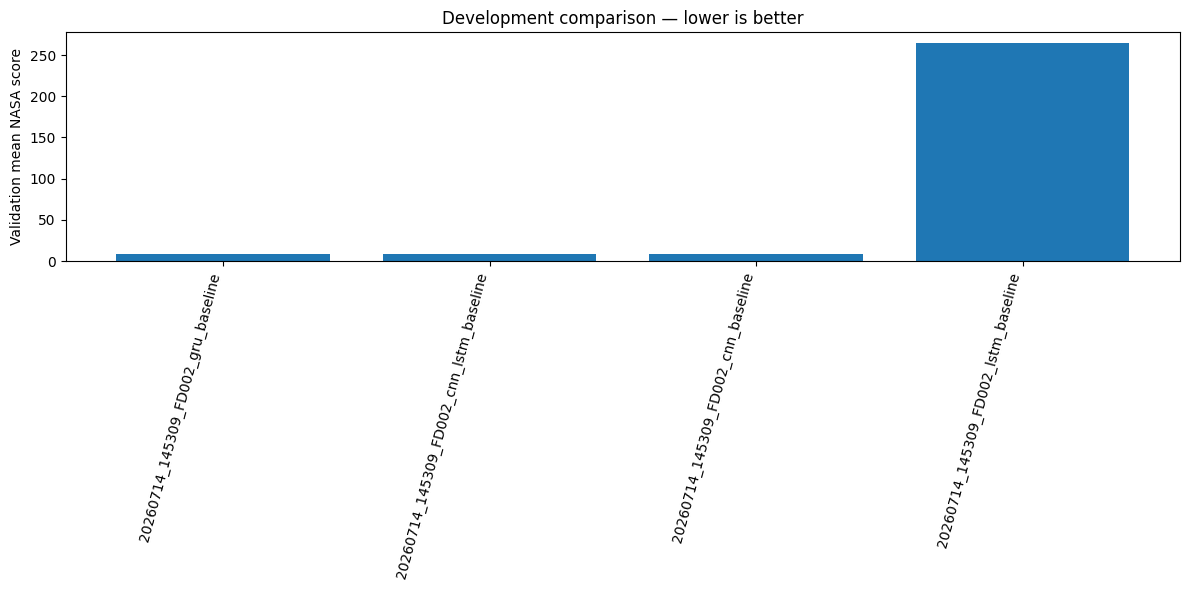

In [13]:
if (
    not development_ranking.empty
    and "validation_MEAN_NASA_SCORE"
    in development_ranking.columns
):
    plot_frame = development_ranking.dropna(
        subset=["validation_MEAN_NASA_SCORE"]
    )

    plt.figure(figsize=(12, 6))
    plt.bar(
        plot_frame["experiment_name"],
        plot_frame["validation_MEAN_NASA_SCORE"],
    )
    plt.xticks(rotation=75, ha="right")
    plt.ylabel("Validation mean NASA score")
    plt.title(
        "Development comparison — lower is better"
    )
    plt.tight_layout()
    plt.show()


## 11. Rank official-test results

The official NASA score is the main final metric. Lower is better.

The official test should be used for the final report, not repeatedly for tuning decisions.


In [14]:
official_columns = [
    column
    for column in [
        "experiment_name",
        "model_family",
        "model_name",
        "external_NASA_SCORE",
        "external_MEAN_NASA_SCORE",
        "external_MAE",
        "external_RMSE",
        "external_R2",
        "external_Bias",
        "external_motor_count",
    ]
    if column in completed_df.columns
]

official_ranking = (
    completed_df[official_columns]
    .sort_values(
        by=[
            column
            for column in [
                "external_NASA_SCORE",
                "external_MAE",
            ]
            if column in completed_df.columns
        ],
        ascending=True,
        na_position="last",
    )
    .reset_index(drop=True)
)

official_ranking


,experiment_name,model_family,model_name,external_NASA_SCORE,external_MEAN_NASA_SCORE,external_MAE,external_RMSE,external_R2,external_Bias,external_motor_count
0,20260714_145309_FD002_random_forest_baseline,tabular,random_forest,1978.820825,NaN,13.092564,17.253192,0.838553,-0.601717,259
1,20260714_145309_FD002_xgboost_baseline,tabular,xgboost,2270.450321,NaN,13.153895,17.104264,0.841328,-0.683114,259
2,20260714_145309_FD002_hist_gradient_boosting_b...,tabular,hist_gradient_boosting,2371.520916,NaN,12.995804,17.426779,0.835288,-0.682238,259
3,20260714_145309_FD002_extra_trees_baseline,tabular,extra_trees,2412.172981,NaN,13.077144,17.372411,0.836314,-0.674771,259
4,20260714_145309_FD002_ridge_alpha_1,tabular,ridge,2707.123204,NaN,17.318600,21.175666,0.756799,-1.256947,259
5,20260714_145309_FD002_gru_baseline,sequence,gru,2713.178164,10.724024,17.371451,22.114988,0.732547,7.935862,253
6,20260714_145309_FD002_linear_default,tabular,linear,2769.613478,NaN,17.483237,21.323913,0.753382,-1.192890,259
7,20260714_145309_FD002_cnn_baseline,sequence,cnn,3045.041679,12.035738,20.214194,25.431825,0.646304,12.896081,253
8,20260714_145309_FD002_cnn_lstm_baseline,sequence,cnn_lstm,4348.088882,17.186122,18.996396,24.681254,0.666874,12.227573,253
9,20260714_145309_FD002_elastic_net_default,tabular,elastic_net,74800.711544,NaN,34.078820,40.209581,0.123101,-11.101948,259


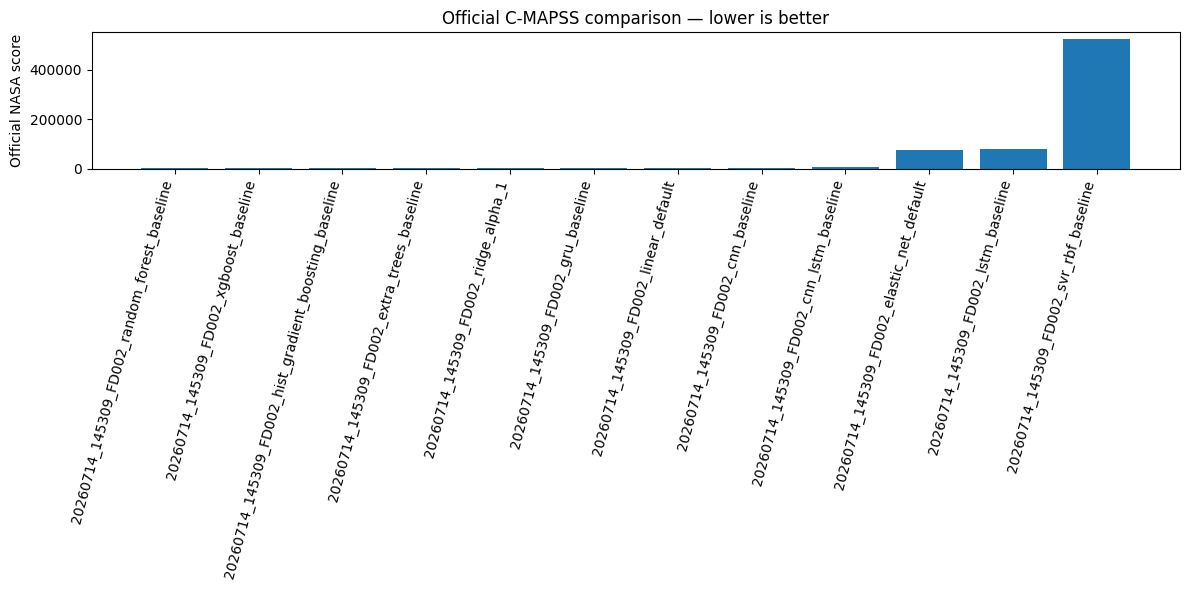

In [15]:
if (
    not official_ranking.empty
    and "external_NASA_SCORE"
    in official_ranking.columns
):
    plot_frame = official_ranking.dropna(
        subset=["external_NASA_SCORE"]
    )

    plt.figure(figsize=(12, 6))
    plt.bar(
        plot_frame["experiment_name"],
        plot_frame["external_NASA_SCORE"],
    )
    plt.xticks(rotation=75, ha="right")
    plt.ylabel("Official NASA score")
    plt.title(
        "Official C-MAPSS comparison — lower is better"
    )
    plt.tight_layout()
    plt.show()


## 12. Compare validation and official performance

This table helps detect models that look strong on the held-out training motors but generalize poorly to the official test engines.


In [16]:
generalization_columns = [
    column
    for column in [
        "experiment_name",
        "model_family",
        "model_name",
        "validation_MAE",
        "external_MAE",
        "validation_RMSE",
        "external_RMSE",
        "validation_MEAN_NASA_SCORE",
        "external_MEAN_NASA_SCORE",
        "external_NASA_SCORE",
    ]
    if column in completed_df.columns
]

generalization_table = completed_df[
    generalization_columns
].copy()

if {
    "validation_MAE",
    "external_MAE",
}.issubset(generalization_table.columns):
    generalization_table[
        "external_minus_validation_MAE"
    ] = (
        generalization_table["external_MAE"]
        - generalization_table["validation_MAE"]
    )

generalization_table.sort_values(
    "external_NASA_SCORE"
    if "external_NASA_SCORE"
    in generalization_table.columns
    else "validation_MAE",
    na_position="last",
)


,experiment_name,model_family,model_name,validation_MAE,external_MAE,validation_RMSE,external_RMSE,validation_MEAN_NASA_SCORE,external_MEAN_NASA_SCORE,external_NASA_SCORE,external_minus_validation_MAE
3,20260714_145309_FD002_random_forest_baseline,tabular,random_forest,16.549685,13.092564,22.079858,17.253192,NaN,NaN,1978.820825,-3.457121
6,20260714_145309_FD002_xgboost_baseline,tabular,xgboost,16.424649,13.153895,22.022356,17.104264,NaN,NaN,2270.450321,-3.270754
5,20260714_145309_FD002_hist_gradient_boosting_b...,tabular,hist_gradient_boosting,16.537103,12.995804,22.122197,17.426779,NaN,NaN,2371.520916,-3.541299
4,20260714_145309_FD002_extra_trees_baseline,tabular,extra_trees,16.455800,13.077144,21.926085,17.372411,NaN,NaN,2412.172981,-3.378656
1,20260714_145309_FD002_ridge_alpha_1,tabular,ridge,19.526171,17.318600,24.282289,21.175666,NaN,NaN,2707.123204,-2.207571
9,20260714_145309_FD002_gru_baseline,sequence,gru,17.044134,17.371451,20.644654,22.114988,8.797872,10.724024,2713.178164,0.327317
0,20260714_145309_FD002_linear_default,tabular,linear,19.604310,17.483237,24.316620,21.323913,NaN,NaN,2769.613478,-2.121074
10,20260714_145309_FD002_cnn_baseline,sequence,cnn,19.939144,20.214194,23.668341,25.431825,9.009403,12.035738,3045.041679,0.275050
11,20260714_145309_FD002_cnn_lstm_baseline,sequence,cnn_lstm,18.270856,18.996396,22.545004,24.681254,9.001192,17.186122,4348.088882,0.725540
2,20260714_145309_FD002_elastic_net_default,tabular,elastic_net,33.552696,34.078820,37.480748,40.209581,NaN,NaN,74800.711544,0.526124


## 13. View learning curves

- Tabular models: training motors versus train/validation MAE.
- Sequence models: epochs versus train/validation metrics.

The curves are loaded from each saved experiment's `extra_tables/learning_curve.csv`.


In [17]:
def plot_saved_learning_curve(
    experiment_name: str,
) -> None:
    loaded = SERVICE.manager.load_experiment(
        experiment_name
    )

    curve = loaded.extra_tables.get(
        "learning_curve"
    )

    if curve is None or curve.empty:
        print(
            f"No learning curve saved for {experiment_name}"
        )
        return

    if {
        "training_groups",
        "train_MAE",
        "validation_MAE",
    }.issubset(curve.columns):
        frame = curve.sort_values(
            "training_groups"
        )

        plt.figure(figsize=(8, 5))
        plt.plot(
            frame["training_groups"],
            frame["train_MAE"],
            marker="o",
            label="Train MAE",
        )
        plt.plot(
            frame["training_groups"],
            frame["validation_MAE"],
            marker="o",
            label="Validation MAE",
        )
        plt.xlabel("Training motors")
        plt.ylabel("MAE")

    else:
        frame = curve.copy()

        if "epoch" not in frame.columns:
            frame = frame.reset_index(
                names="epoch"
            )
            frame["epoch"] += 1

        metric = next(
            (
                name
                for name in (
                    "mae",
                    "rmse",
                    "loss",
                )
                if name in frame.columns
            ),
            None,
        )

        if metric is None:
            print(
                f"No supported sequence metrics in "
                f"{experiment_name}"
            )
            return

        plt.figure(figsize=(8, 5))
        plt.plot(
            frame["epoch"],
            frame[metric],
            label=f"Train {metric}",
        )

        validation_metric = f"val_{metric}"

        if validation_metric in frame.columns:
            plt.plot(
                frame["epoch"],
                frame[validation_metric],
                label=f"Validation {metric}",
            )

        plt.xlabel("Epoch")
        plt.ylabel(metric.upper())

    plt.title(
        f"Learning curve — {experiment_name}"
    )
    plt.legend()
    plt.tight_layout()
    plt.show()


# Example:
# plot_saved_learning_curve(completed_names[0])


## 14. Export final comparison files


In [18]:
EXPORT_FOLDER = PROJECT_ROOT / "experiment_comparisons"
EXPORT_FOLDER.mkdir(exist_ok=True)

development_path = (
    EXPORT_FOLDER
    / f"development_ranking_{RUN_PREFIX}.csv"
)

official_path = (
    EXPORT_FOLDER
    / f"official_ranking_{RUN_PREFIX}.csv"
)

generalization_path = (
    EXPORT_FOLDER
    / f"generalization_comparison_{RUN_PREFIX}.csv"
)

development_ranking.to_csv(
    development_path,
    index=False,
)

official_ranking.to_csv(
    official_path,
    index=False,
)

generalization_table.to_csv(
    generalization_path,
    index=False,
)

print(development_path)
print(official_path)
print(generalization_path)


/home/lewagon/code/feremiev/predictive_maintenance/predictive_maintenance_dds04/experiment_comparisons/development_ranking_20260714_145309.csv
/home/lewagon/code/feremiev/predictive_maintenance/predictive_maintenance_dds04/experiment_comparisons/official_ranking_20260714_145309.csv
/home/lewagon/code/feremiev/predictive_maintenance/predictive_maintenance_dds04/experiment_comparisons/generalization_comparison_20260714_145309.csv


## 15. Focused tuning template

After the baseline comparison, copy only the strongest models into the lists below and vary one or two parameters at a time.

Suggested next comparisons:

### Tabular

- Ridge: `alpha = 0.1, 1, 10`
- Random Forest / Extra Trees:
  - `min_samples_leaf = 2, 5, 10`
  - `max_features = "sqrt", 0.5, 1.0`
- HistGradientBoosting:
  - `learning_rate = 0.03, 0.05, 0.08`
  - `max_leaf_nodes = 15, 31, 63`
  - `min_samples_leaf = 20, 40`
- XGBoost:
  - `max_depth = 3, 5, 7`
  - `learning_rate = 0.03, 0.05`
  - `min_child_weight = 3, 5, 10`
- SVR:
  - `C = 1, 10, 100`
  - `epsilon = 0.1, 1, 5`

### Sequence

Change only one dimension per experiment:

- Window size: `30, 40, 50`
- Batch size: `32, 64`
- Learning rate: `0.001, 0.0005`
- Architecture: LSTM versus GRU versus CNN versus CNN-LSTM

Keep the validation motors, seed, feature set, RUL clipping, and official-test protocol unchanged.
